In [ ]:
!pip install zenodo_get -q

!zenodo_get 10.5281/zenodo.11449658

import os
os.listdir('/content')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.6/254.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.4/83.4 kB 4.6 MB/s eta 0:00:00
INFO: Output directory: /content
INFO: Title: Dataset for "Flavor network and the principles of food pairing"
INFO: Total size: 829.6 kB
INFO: Number of files: 1
SUCCESS: All specified files have been processed.


['.config', 'flavor_network_data.zip', 'sample_data']

In [ ]:
import zipfile
with zipfile.ZipFile('/content/flavor_network_data.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/flavor_network')

import os
for root, dirs, files in os.walk('/content/flavor_network'):
    for file in files:
        print(os.path.join(root, file))

/content/flavor_network/flavor_network_backbone/flavor_network_backbone_edges.tsv
/content/flavor_network/flavor_network_backbone/README
/content/flavor_network/flavor_network_backbone/flavor_network_backbone_nodes.tsv
/content/flavor_network/ingr_comp/README.md
/content/flavor_network/ingr_comp/LICENSE
/content/flavor_network/ingr_comp/ingr_info.tsv
/content/flavor_network/ingr_comp/comp_info.tsv
/content/flavor_network/ingr_comp/ingr_comp.tsv
/content/flavor_network/__MACOSX/._scirep-cuisines-detail
/content/flavor_network/__MACOSX/._ingr_comp
/content/flavor_network/__MACOSX/._flavor_network_backbone
/content/flavor_network/__MACOSX/flavor_network_backbone/._flavor_network_backbone_edges.tsv
/content/flavor_network/__MACOSX/flavor_network_backbone/._flavor_network_backbone_nodes.tsv
/content/flavor_network/__MACOSX/flavor_network_backbone/._README
/content/flavor_network/__MACOSX/ingr_comp/._LICENSE
/content/flavor_network/__MACOSX/ingr_comp/._comp_info.tsv
/content/flavor_network/_

In [ ]:
import pandas as pd

nodes = pd.read_csv('/content/flavor_network/flavor_network_backbone/flavor_network_backbone_nodes.tsv', sep='\t')
edges = pd.read_csv('/content/flavor_network/flavor_network_backbone/flavor_network_backbone_edges.tsv', sep='\t')

print("NODES:")
print(nodes.head())
print("\nEDGES:")
print(edges.head())

NODES:
      almond  573.0  262.0  0.06057105  209.0  187.0  199.0
0       leek  844.0  526.0    0.011385    0.0  131.0   61.0
1  blueberry  440.0  263.0    0.004723  255.0  255.0    0.0
2       wood  634.0  387.0    0.000571  255.0  118.0   51.0
3     caviar  659.0  573.0    0.002248  124.0  169.0  255.0
4       fish  692.0  634.0    0.089625  124.0  169.0  255.0

EDGES:
               lemon juice         lemon   3
0          brussels sprout         onion   8
1            sunflower oil     asparagus   1
2  cabernet sauvignon wine         apple  86
3  cabernet sauvignon wine  jamaican rum  88
4  cabernet sauvignon wine           rum  86


In [ ]:
import networkx as nx

G = nx.from_pandas_edgelist(edges, source=edges.columns[0], target=edges.columns[1], edge_attr=edges.columns[2])

# basic stats
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")
print(f"Network density: {nx.density(G):.4f}")

Nodes: 376
Edges: 917
Average degree: 4.88
Network density: 0.0130


In [ ]:
#top 10 connected ingredients (hubs)
degree_df = pd.DataFrame(G.degree(), columns=['ingredient', 'degree'])
degree_df = degree_df.sort_values('degree', ascending=False)
print("\nTop 10 most connected ingredients:")
print(degree_df.head(10).to_string(index=False))


Top 10 most connected ingredients:
     ingredient  degree
   roasted beef      49
      black tea      47
     strawberry      42
           beer      33
     white wine      25
          apple      25
    blue cheese      24
parmesan cheese      23
 cheddar cheese      22
   swiss cheese      20


In [ ]:
#CC and centrality stuff
import numpy as np

avg_clustering = nx.average_clustering(G)
print(f"Average clustering coefficient: {avg_clustering:.4f}")

degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)

centrality_df = pd.DataFrame({
    'ingredient': list(degree_centrality.keys()),
    'degree_centrality': list(degree_centrality.values()),
    'betweenness_centrality': list(betweenness_centrality.values()),
    'closeness_centrality': list(closeness_centrality.values())
}).sort_values('degree_centrality', ascending=False)

print("\nTop 10 ingredients by degree centrality:")
print(centrality_df.head(10).to_string(index=False))

Average clustering coefficient: 0.3122

Top 10 ingredients by degree centrality:
     ingredient  degree_centrality  betweenness_centrality  closeness_centrality
   roasted beef           0.130667                0.323440              0.338386
      black tea           0.125333                0.349444              0.349620
     strawberry           0.112000                0.143958              0.291301
           beer           0.088000                0.268226              0.351033
     white wine           0.066667                0.121679              0.346138
          apple           0.066667                0.121250              0.318828
    blue cheese           0.064000                0.042662              0.286735
parmesan cheese           0.061333                0.054416              0.291546
 cheddar cheese           0.058667                0.018866              0.268980
   swiss cheese           0.053333                0.014038              0.268357


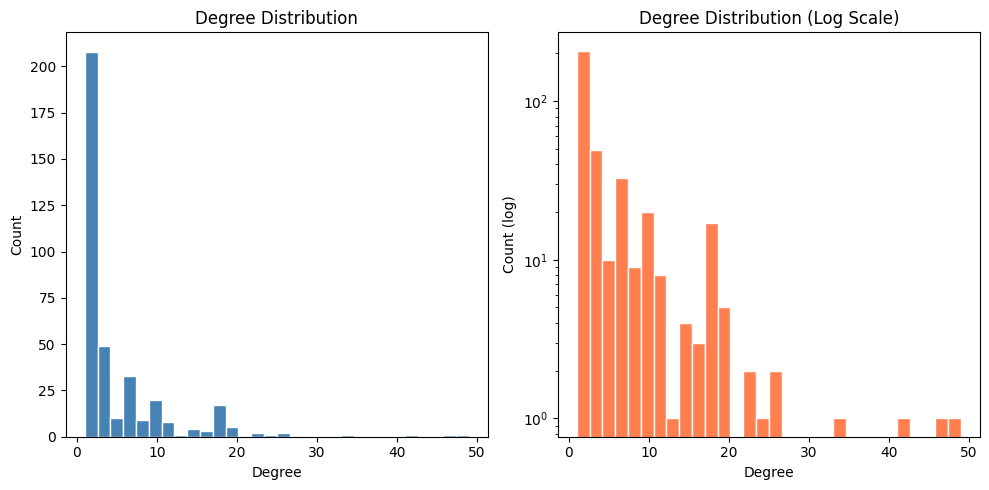

In [ ]:
#degree distribution
import matplotlib.pyplot as plt

degrees = [d for _, d in G.degree()]

plt.figure(figsize=(10, 5))

#linear
plt.subplot(1, 2, 1)
plt.hist(degrees, bins=30, color='steelblue', edgecolor='white')
plt.title('Degree Distribution')
plt.xlabel('Degree')
plt.ylabel('Count')

# log scale
plt.subplot(1, 2, 2)
plt.hist(degrees, bins=30, color='coral', edgecolor='white', log=True)
plt.title('Degree Distribution (Log Scale)')
plt.xlabel('Degree')
plt.ylabel('Count (log)')

plt.tight_layout()
plt.show()

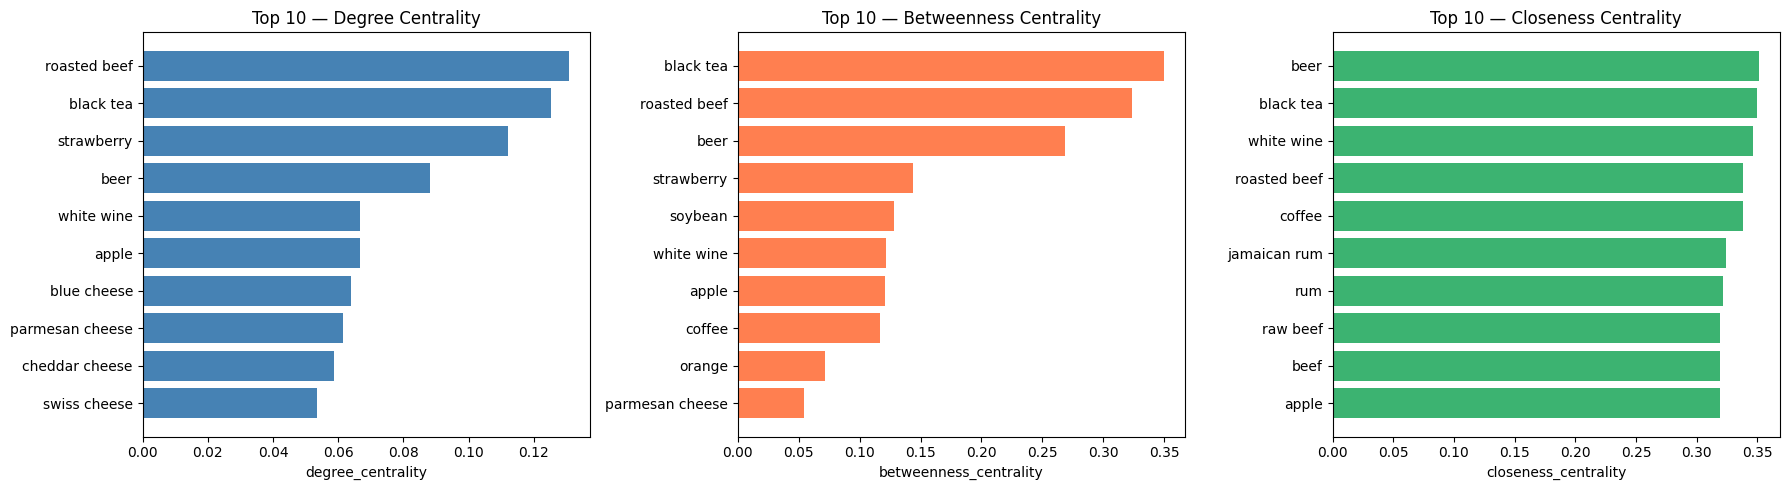

In [ ]:
#top inridients by centrality measures
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

measures = ['degree_centrality', 'betweenness_centrality', 'closeness_centrality']
colors = ['steelblue', 'coral', 'mediumseagreen']
titles = ['Degree Centrality', 'Betweenness Centrality', 'Closeness Centrality']

for ax, measure, color, title in zip(axes, measures, colors, titles):
    top10 = centrality_df.nlargest(10, measure)[['ingredient', measure]]
    ax.barh(top10['ingredient'], top10[measure], color=color)
    ax.invert_yaxis()
    ax.set_title(f'Top 10 — {title}')
    ax.set_xlabel(measure)

plt.tight_layout()
plt.show()

In [ ]:
# Degree assortativity

assortativity = nx.degree_assortativity_coefficient(G)
print(f"Degree assortativity coefficient: {assortativity:.4f}")

if assortativity > 0.1:
    print("→ Assortative: high-degree ingredients tend to connect to other high-degree ingredients")
elif assortativity < -0.1:
    print("→ Disassortative: high-degree ingredients tend to connect to low-degree ingredients")
else:
    print("→ Neutral: no strong preference")

Degree assortativity coefficient: -0.1563
→ Disassortative: high-degree ingredients tend to connect to low-degree ingredients


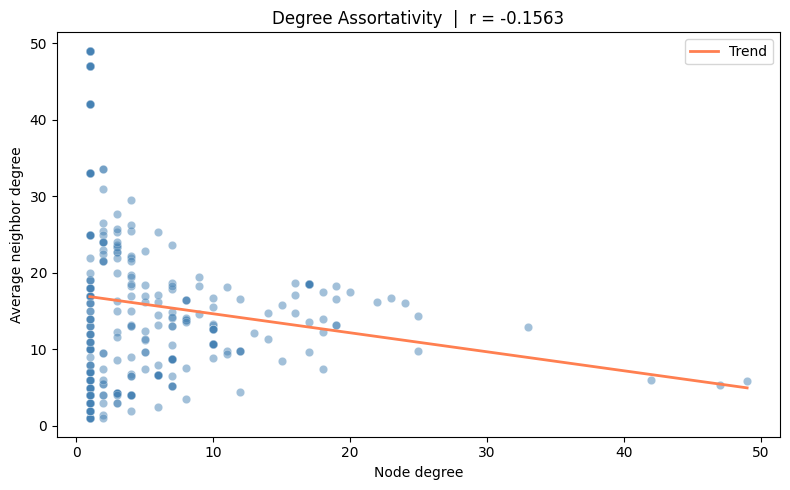

In [ ]:
avg_neighbor_degree = nx.average_neighbor_degree(G)
node_degree = dict(G.degree())

x = [node_degree[n] for n in G.nodes()]
y = [avg_neighbor_degree[n] for n in G.nodes()]

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.3)
plt.xlabel('Node degree')
plt.ylabel('Average neighbor degree')
plt.title(f'Degree Assortativity  |  r = {assortativity:.4f}')

# trend line
z = np.polyfit(x, y, 1)
p_fit = np.poly1d(z)
x_sorted = sorted(x)
plt.plot(x_sorted, p_fit(x_sorted), color='coral', linewidth=2, label='Trend')
plt.legend()
plt.tight_layout()
plt.show()

# Small world test

In [ ]:
largest_cc = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc).copy()

print(f"Largest connected component: {G_lcc.number_of_nodes()} nodes, {G_lcc.number_of_edges()} edges")
print(f"(Original graph had {G.number_of_nodes()} nodes)\n")

real_clustering = nx.average_clustering(G_lcc)
real_avg_path = nx.average_shortest_path_length(G_lcc)

print(f"Real graph — avg clustering:       {real_clustering:.4f}")
print(f"Real graph — avg shortest path:    {real_avg_path:.4f}")

Largest connected component: 362 nodes, 902 edges
(Original graph had 376 nodes)

Real graph — avg clustering:       0.3104
Real graph — avg shortest path:    4.2685


In [ ]:
#building ER model
n = G_lcc.number_of_nodes()
m = G_lcc.number_of_edges()
p = (2 * m) / (n * (n - 1))

random_clusterings = []
random_paths = []

print("Generating random graphs for comparison...")
for i in range(10):
    R = nx.erdos_renyi_graph(n, p)
    R_lcc = R.subgraph(max(nx.connected_components(R), key=len)).copy()
    random_clusterings.append(nx.average_clustering(R_lcc))
    random_paths.append(nx.average_shortest_path_length(R_lcc))
    print(f"  Random graph {i+1}/10 done")

rand_clustering_mean = np.mean(random_clusterings)
rand_path_mean = np.mean(random_paths)

print(f"\nRandom graph — avg clustering:     {rand_clustering_mean:.4f}")
print(f"Random graph — avg shortest path:  {rand_path_mean:.4f}")

Generating random graphs for comparison...
  Random graph 1/10 done
  Random graph 2/10 done
  Random graph 3/10 done
  Random graph 4/10 done
  Random graph 5/10 done
  Random graph 6/10 done
  Random graph 7/10 done
  Random graph 8/10 done
  Random graph 9/10 done
  Random graph 10/10 done

Random graph — avg clustering:     0.0152
Random graph — avg shortest path:  3.8469


In [ ]:
sigma = (real_clustering / rand_clustering_mean) / (real_avg_path / rand_path_mean)

print("\n--- Small World Test ---")
print(f"Clustering ratio  (C_real / C_random): {real_clustering / rand_clustering_mean:.4f}")
print(f"Path length ratio (L_real / L_random): {real_avg_path / rand_path_mean:.4f}")
print(f"\nSigma (small world coefficient): {sigma:.4f}")

if sigma > 1:
    print("\n✓ SMALL WORLD confirmed — high clustering, short paths")
else:
    print("\n✗ Small world NOT confirmed")


--- Small World Test ---
Clustering ratio  (C_real / C_random): 20.4775
Path length ratio (L_real / L_random): 1.1096

Sigma (small world coefficient): 18.4548

✓ SMALL WORLD confirmed — high clustering, short paths


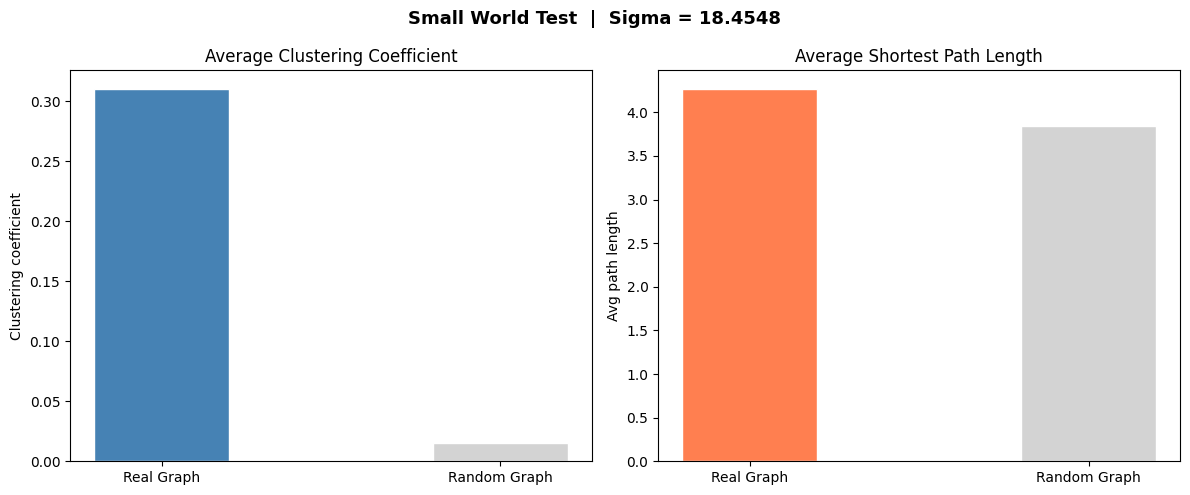

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Real Graph', 'Random Graph'],
            [real_clustering, rand_clustering_mean],
            color=['steelblue', 'lightgray'], edgecolor='white', width=0.4)
axes[0].set_title('Average Clustering Coefficient')
axes[0].set_ylabel('Clustering coefficient')

axes[1].bar(['Real Graph', 'Random Graph'],
            [real_avg_path, rand_path_mean],
            color=['coral', 'lightgray'], edgecolor='white', width=0.4)
axes[1].set_title('Average Shortest Path Length')
axes[1].set_ylabel('Avg path length')

plt.suptitle(f'Small World Test  |  Sigma = {sigma:.4f}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Clustering coefficient ───────────────────────────────────
avg_clustering = nx.average_clustering(G)
print(f"Average clustering coefficient : {avg_clustering:.4f}")

# Per-node clustering (optional)
node_clustering = nx.clustering(G)
top5_cc = sorted(node_clustering.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 nodes by clustering coefficient:")
for node, cc in top5_cc:
    print(f"  {node:<25} {cc:.4f}")

# ── Average path length ──────────────────────────────────────
# Only works if the graph is connected — check first
if nx.is_connected(G):
    avg_path = nx.average_shortest_path_length(G)
    print(f"\nAverage path length : {avg_path:.4f}")
else:
    # Use the largest connected component instead
    lcc_nodes = max(nx.connected_components(G), key=len)
    G_lcc = G.subgraph(lcc_nodes).copy()
    avg_path = nx.average_shortest_path_length(G_lcc)
    print(f"\nGraph is disconnected — computed on LCC ({len(lcc_nodes)} nodes)")
    print(f"Average path length (LCC) : {avg_path:.4f}")


Average clustering coefficient : 0.3122

Top 5 nodes by clustering coefficient:
  champagne wine            1.0000
  porcini                   1.0000
  shiitake                  1.0000
  enokidake                 1.0000
  matsutake                 1.0000

Graph is disconnected — computed on LCC (362 nodes)
Average path length (LCC) : 4.2685


# What the original paper did not cover?

1. Community detection

2. Network robustness

3. Ingredient role analysis (core vs periphery)

6. Surprise pairings - Find ingredient pairs that are highly connected in the flavor network (share many compounds) but rarely appear together in recipes.




# Community detection

In [ ]:
import community.community_louvain as community_louvain
import matplotlib.cm as cm

partition = community_louvain.best_partition(G, random_state=42)

num_communities = len(set(partition.values()))
print(f"Louvain communities found: {num_communities}")

from collections import Counter
community_sizes = Counter(partition.values())
print("\nCommunity sizes (community_id: num_ingredients):")
for comm_id, size in sorted(community_sizes.items(), key=lambda x: -x[1]):
    print(f"  Community {comm_id}: {size} ingredients")

Louvain communities found: 18

Community sizes (community_id: num_ingredients):
  Community 8: 69 ingredients
  Community 9: 59 ingredients
  Community 7: 54 ingredients
  Community 4: 46 ingredients
  Community 5: 31 ingredients
  Community 12: 25 ingredients
  Community 13: 25 ingredients
  Community 1: 15 ingredients
  Community 11: 15 ingredients
  Community 10: 8 ingredients
  Community 15: 6 ingredients
  Community 3: 5 ingredients
  Community 16: 5 ingredients
  Community 17: 4 ingredients
  Community 6: 3 ingredients
  Community 14: 2 ingredients
  Community 0: 2 ingredients
  Community 2: 2 ingredients


In [ ]:
# group ingredients by community
from collections import defaultdict

communities = defaultdict(list)
for ingredient, comm_id in partition.items():
    communities[comm_id].append(ingredient)

print("Top 5 communities and their ingredients:\n")
top5 = sorted(communities.items(), key=lambda x: -len(x[1]))[:5]

for comm_id, ingredients in top5:
    print(f"Community {comm_id} ({len(ingredients)} ingredients):")
    print(f"  {', '.join(sorted(ingredients))}\n")

Top 5 communities and their ingredients:

Community 8 (69 ingredients):
  almond, bacon, baked potato, barley, beech, beef, beef broth, beet, brassica, brussels sprout, butter, cabbage, chervil, chicken, chicken broth, chive, cilantro, clam, crab, cucumber, cured pork, fenugreek, garlic, ham, horseradish, kohlrabi, lamb, leek, lentil, lobster, macadamia nut, meat, milk fat, mutton, nira, onion, oyster, pea, peanut, peanut butter, peanut oil, popcorn, pork, pork liver, pork sausage, potato, potato chip, pumpkin, raisin, raw beef, roasted almond, roasted beef, roasted meat, roasted peanut, roasted pork, scallion, scallop, shallot, shrimp, smoke, smoked sausage, sweet potato, turkey, turnip, walnut, wasabi, wheat, yeast, yogurt

Community 9 (59 ingredients):
  black tea, buckwheat, caraway, cardamom, carnation, carrot, celery, celery oil, chamomile, cocoa, coffee, dill, endive, flower, gardenia, geranium, green tea, japanese plum, jasmine, jasmine tea, katsuobushi, lavender, leaf, lemon p

In [ ]:
nodes = pd.read_csv(
    '/content/flavor_network/flavor_network_backbone/flavor_network_backbone_nodes.tsv',
    sep='\t',
    header=None,
    names=['ingredient', 'x', 'y', 'prevalence', 'r', 'g', 'b']
)

nodes['r'] = nodes['r'].astype(int)
nodes['g'] = nodes['g'].astype(int)
nodes['b'] = nodes['b'].astype(int)

print(nodes.head(10))
print(f"\nTotal ingredients: {len(nodes)}")

         ingredient      x      y  prevalence    r    g    b
0            almond  573.0  262.0    0.060571  209  187  199
1              leek  844.0  526.0    0.011385    0  131   61
2         blueberry  440.0  263.0    0.004723  255  255    0
3              wood  634.0  387.0    0.000571  255  118   51
4            caviar  659.0  573.0    0.002248  124  169  255
5              fish  692.0  634.0    0.089625  124  169  255
6          mandarin  473.0  214.0    0.002034  255  255    0
7  roquefort cheese  392.0  569.0    0.000960  255  255  255
8             bacon  747.0  417.0    0.029626  230    0    0
9     romano cheese  378.0  542.0    0.008753  255  255  255

Total ingredients: 376


In [ ]:
color_to_category = {
    (255, 255,   0): 'Fruits',
    (255, 255, 255): 'Dairy',
    (210, 105,  30): 'Spices',
    (139,   0,   0): 'Alcoholic beverages',
    (107, 142,  35): 'Nuts and seeds',
    (124, 169, 255): 'Seafoods',
    (255,   0,   0): 'Meats',
    (144, 238, 144): 'Herbs',
    (128, 128,   0): 'Plant derivatives',
    (  0, 128,   0): 'Vegetables',
    (255, 182, 193): 'Flowers',
    (210, 180, 140): 'Animal products',
    (255, 165,   0): 'Plants',
    (255, 228, 196): 'Cereal',
}

def rgb_to_category(r, g, b):
    min_dist = float('inf')
    best_category = 'Unknown'
    for (cr, cg, cb), category in color_to_category.items():
        dist = ((r - cr)**2 + (g - cg)**2 + (b - cb)**2) ** 0.5
        if dist < min_dist:
            min_dist = dist
            best_category = category
    return best_category

nodes['category'] = nodes.apply(
    lambda row: rgb_to_category(row['r'], row['g'], row['b']), axis=1
)

print("Category distribution in nodes:")
print(nodes['category'].value_counts())

Category distribution in nodes:
category
Vegetables             64
Fruits                 63
Flowers                31
Plant derivatives      29
Seafoods               27
Plants                 25
Dairy                  25
Alcoholic beverages    25
Meats                  24
Herbs                  23
Cereal                 22
Spices                 14
Animal products         4
Name: count, dtype: int64


In [ ]:
nodes['community'] = nodes['ingredient'].map(partition)

# which categories dominate which communities?
crosstab = pd.crosstab(nodes['community'], nodes['category'])

# dominant category per community
crosstab['dominant_category'] = crosstab.idxmax(axis=1)
crosstab['dominant_pct'] = (crosstab.drop(columns=['dominant_category']).max(axis=1) / crosstab.drop(columns=['dominant_category']).sum(axis=1) * 100).round(1)

print("Community -> Dominant food category:\n")
#print(crosstab[['dominant_category', 'dominant_pct']].to_string())
print(crosstab[['dominant_category', 'dominant_pct']].sort_values('dominant_pct', ascending=False).to_string())


Community -> Dominant food category:

category     dominant_category  dominant_pct
community                                   
0                      Flowers         100.0
2                       Cereal         100.0
14                     Flowers         100.0
3                   Vegetables         100.0
6                        Meats         100.0
17                     Flowers         100.0
11                    Seafoods          93.3
1                   Vegetables          80.0
16                      Cereal          80.0
10                      Cereal          75.0
4                       Fruits          71.7
5                        Dairy          71.0
12                      Plants          60.0
15                  Vegetables          50.0
13                      Fruits          48.0
7          Alcoholic beverages          38.9
8                   Vegetables          29.0
9            Plant derivatives          22.0


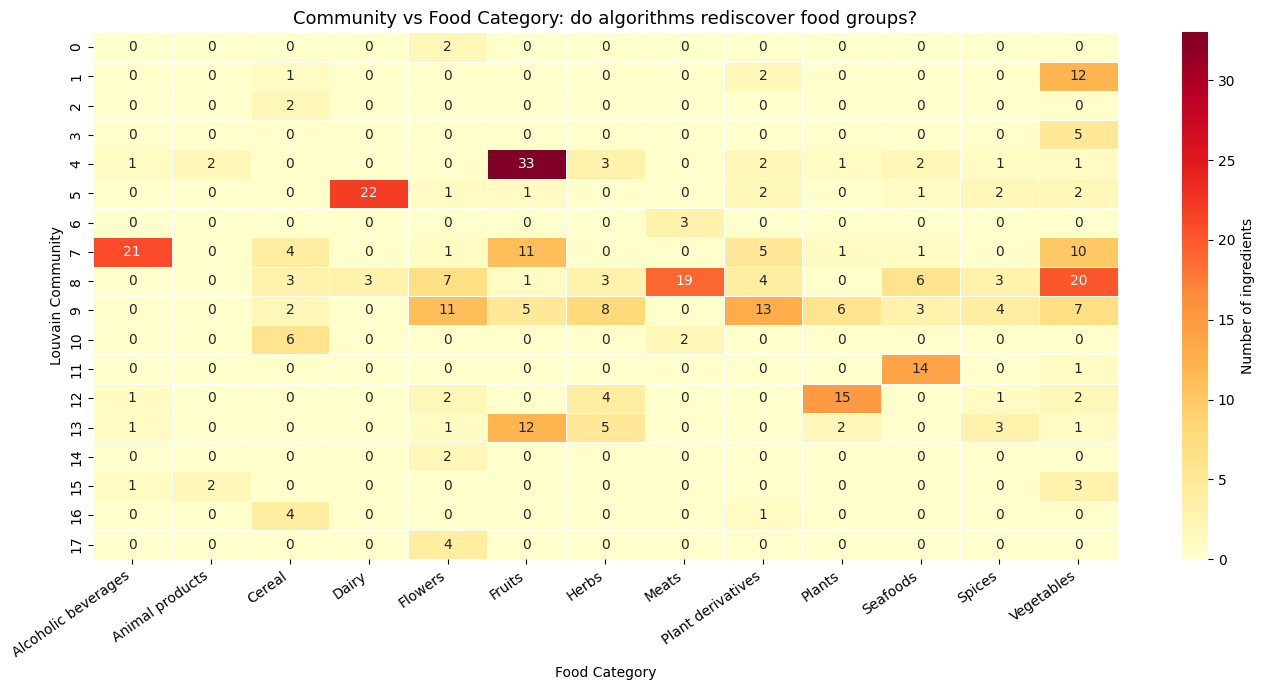

In [ ]:
0import seaborn as sns

plt.figure(figsize=(14, 7))
sns.heatmap(
    crosstab.drop(columns=['dominant_category', 'dominant_pct']),
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Number of ingredients'}
)
plt.title('Community vs Food Category: do algorithms rediscover food groups?', fontsize=13)
plt.xlabel('Food Category')
plt.ylabel('Louvain Community')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
from networkx.algorithms.community import girvan_newman
import itertools

gn_communities = girvan_newman(G)

limited = itertools.islice(gn_communities, 8)
gn_results = []
for communities_gn in limited:
    gn_results.append(list(communities_gn))

print("\nGirvan-Newman splits:")
for i, result in enumerate(gn_results):
    print(f"  Split {i+1}: {len(result)} communities, sizes: {sorted([len(c) for c in result], reverse=True)}")


Girvan-Newman splits:
  Split 1: 7 communities, sizes: [239, 123, 5, 3, 2, 2, 2]
  Split 2: 8 communities, sizes: [141, 123, 98, 5, 3, 2, 2, 2]
  Split 3: 9 communities, sizes: [123, 98, 87, 54, 5, 3, 2, 2, 2]
  Split 4: 10 communities, sizes: [115, 98, 87, 54, 8, 5, 3, 2, 2, 2]
  Split 5: 11 communities, sizes: [115, 89, 87, 54, 9, 8, 5, 3, 2, 2, 2]
  Split 6: 12 communities, sizes: [109, 89, 87, 54, 9, 8, 6, 5, 3, 2, 2, 2]
  Split 7: 13 communities, sizes: [93, 89, 87, 54, 16, 9, 8, 6, 5, 3, 2, 2, 2]
  Split 8: 14 communities, sizes: [93, 87, 71, 54, 18, 16, 9, 8, 6, 5, 3, 2, 2, 2]


In [ ]:
from networkx.algorithms.community import label_propagation_communities

lp_communities = list(label_propagation_communities(G))
print(f"Label Propagation communities found: {len(lp_communities)}")
print("\nCommunity sizes:")
for i, comm in enumerate(sorted(lp_communities, key=len, reverse=True)):
    print(f"  Community {i}: {len(comm)} ingredients")

Label Propagation communities found: 45

Community sizes:
  Community 0: 55 ingredients
  Community 1: 47 ingredients
  Community 2: 43 ingredients
  Community 3: 37 ingredients
  Community 4: 28 ingredients
  Community 5: 19 ingredients
  Community 6: 13 ingredients
  Community 7: 11 ingredients
  Community 8: 9 ingredients
  Community 9: 9 ingredients
  Community 10: 6 ingredients
  Community 11: 5 ingredients
  Community 12: 5 ingredients
  Community 13: 5 ingredients
  Community 14: 4 ingredients
  Community 15: 4 ingredients
  Community 16: 4 ingredients
  Community 17: 4 ingredients
  Community 18: 4 ingredients
  Community 19: 4 ingredients
  Community 20: 4 ingredients
  Community 21: 3 ingredients
  Community 22: 3 ingredients
  Community 23: 3 ingredients
  Community 24: 3 ingredients
  Community 25: 3 ingredients
  Community 26: 3 ingredients
  Community 27: 3 ingredients
  Community 28: 3 ingredients
  Community 29: 2 ingredients
  Community 30: 2 ingredients
  Community 31

In [ ]:
from networkx.algorithms.community.quality import modularity

# louvain modularity
louvain_comms = [set(ing for ing, c in partition.items() if c == cid)
                 for cid in set(partition.values())]
louvain_mod = modularity(G, louvain_comms)

# label propagation modularity
lp_mod = modularity(G, lp_communities)

# best Girvan-Newman split modularity
gn_best = [set(c) for c in gn_results[-1]]
gn_mod = modularity(G, gn_best)

print("=" * 45)
print(f"{'Method':<25} {'Communities':>12} {'Modularity':>10}")
print("=" * 45)
print(f"{'Louvain':<25} {num_communities:>12} {louvain_mod:>10.4f}")
print(f"{'Label Propagation':<25} {len(lp_communities):>12} {lp_mod:>10.4f}")
print(f"{'Girvan-Newman':<25} {len(gn_best):>12} {gn_mod:>10.4f}")
print("=" * 45)

Method                     Communities Modularity
Louvain                             18     0.7834
Label Propagation                   45     0.7713
Girvan-Newman                       14     0.7187


/tmp/ipykernel_1925/1708073576.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', num_communities)


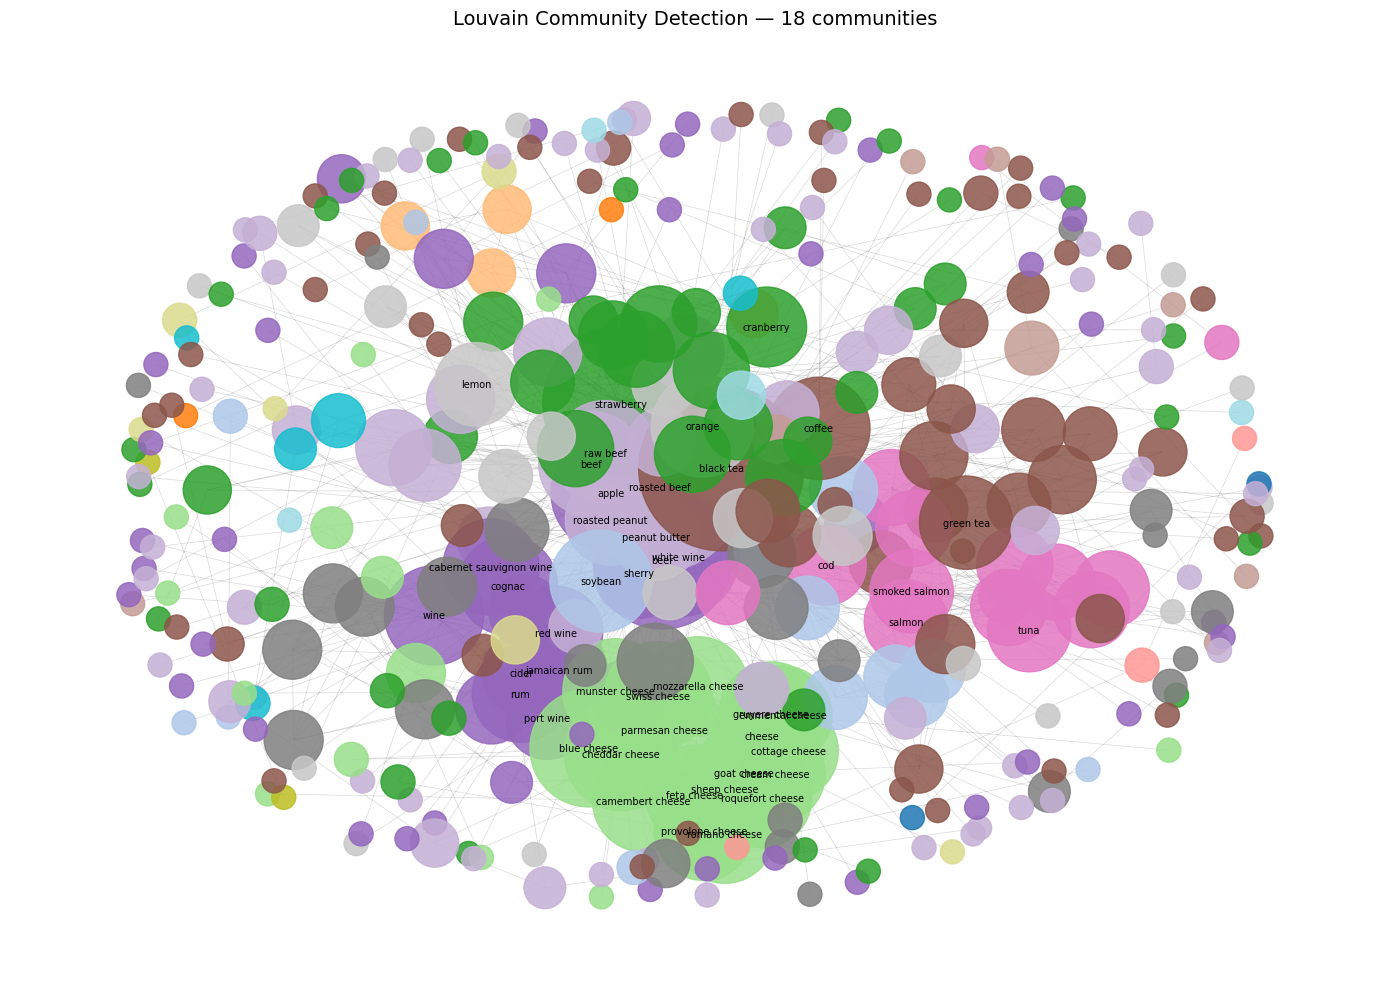

In [ ]:
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42, k=0.5)

cmap = cm.get_cmap('tab20', num_communities)
node_colors = [cmap(partition[node]) for node in G.nodes()]
node_sizes = [300 * nx.degree_centrality(G)[node] * len(G.nodes()) for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                       node_size=node_sizes, alpha=0.85)
nx.draw_networkx_edges(G, pos, alpha=0.15, width=0.5)

high_degree_nodes = {n: n for n in G.nodes() if G.degree(n) > 10}
nx.draw_networkx_labels(G, pos, labels=high_degree_nodes, font_size=7)

plt.title(f'Louvain Community Detection — {num_communities} communities', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

# Unexpected Pairings

Identifying ingredient pairs that have strong connections in the Flavor Network (high edge weight / many shared flavor compounds) but rarely appear together in actual recipes.

basics of the code:
1. Count ingredient co-occurrences across all recipes.
2. Use flavor network edge weights from the backbone TSV.
3. Compute an "unexpectedness" score:

       flavor_weight / (recipe_cooccurrence + 1)

4. Rank pairs with high flavor similarity but low recipe usage to discover potentially overlooked combinations.

In [ ]:
recipe_files = [
    "/content/flavor_network/scirep-cuisines-detail/allr_recipes.txt",
    "/content/flavor_network/scirep-cuisines-detail/epic_recipes.txt",
    "/content/flavor_network/scirep-cuisines-detail/menu_recipes.txt"
]

recipes = []

for file in recipe_files:

    with open(file, "r", encoding="utf-8") as f:

        for line in f:

            parts = line.strip().split("\t")

            if len(parts) < 3:
                continue

            # Skip cuisine label
            ingredients = set(parts[1:])

            recipes.append(ingredients)

print(f"Total recipes loaded: {len(recipes)}")

Total recipes loaded: 57320


In [ ]:
ingredient_freq = Counter()

for recipe in recipes:
    ingredient_freq.update(recipe)

print(f"Unique ingredients: {len(ingredient_freq)}")


Unique ingredients: 383


In [ ]:
from itertools import combinations

pair_freq = Counter()

for recipe in recipes:

    for pair in combinations(sorted(recipe), 2):

        pair_freq[pair] += 1

print(f"Unique ingredient pairs: {len(pair_freq)}")

Unique ingredient pairs: 30358


In [ ]:
edges = pd.read_csv(
    "/content/flavor_network/flavor_network_backbone/flavor_network_backbone_edges.tsv",
    sep="\t",
    header=None,
    names=["ingredient_1", "ingredient_2", "weight"]
)

print(f"Flavor network edges: {len(edges)}")

Flavor network edges: 1834


In [ ]:
results = []

MIN_INGREDIENT_FREQ = 10

for _, row in edges.iterrows():

    ing1 = row["ingredient_1"]
    ing2 = row["ingredient_2"]
    weight = row["weight"]

    # Ignore ingredients that barely occur
    if ingredient_freq[ing1] < MIN_INGREDIENT_FREQ:
        continue

    if ingredient_freq[ing2] < MIN_INGREDIENT_FREQ:
        continue

    pair = tuple(sorted((ing1, ing2)))

    cooccur = pair_freq.get(pair, 0)

    # High weight + low recipe usage
    unexpectedness = weight / (cooccur + 1)

    results.append([
        ing1,
        ing2,
        weight,
        cooccur,
        ingredient_freq[ing1],
        ingredient_freq[ing2],
        unexpectedness
    ])

In [ ]:
unexpected_df = pd.DataFrame(
    results,
    columns=[
        "ingredient_1",
        "ingredient_2",
        "flavor_weight",
        "recipe_cooccurrence",
        "freq_1",
        "freq_2",
        "unexpectedness"
    ]
)

print(f"Candidate pairings: {len(unexpected_df)}")

Candidate pairings: 508


In [ ]:
rare_pairs = unexpected_df[
    unexpected_df["recipe_cooccurrence"] <= 2
].copy()

rare_pairs = rare_pairs.sort_values(
    "unexpectedness",
    ascending=False
)

print("\nTop 20 Unexpected Pairings\n")

print(
    rare_pairs[
        [
            "ingredient_1",
            "ingredient_2",
            "flavor_weight",
            "recipe_cooccurrence",
            "unexpectedness"
        ]
    ].head(20)
)


Top 20 Unexpected Pairings

    ingredient_1 ingredient_2  flavor_weight  recipe_cooccurrence  \
1        porcini    enokidake            117                    0   
2        porcini    matsutake            117                    0   
256      porcini    matsutake            117                    0   
255      porcini    enokidake            117                    0   
178       sherry         beer            103                    0   
432       sherry         beer            103                    0   
215         beer       cognac             99                    0   
469         beer       cognac             99                    0   
286        guava   strawberry             83                    0   
32         guava   strawberry             83                    0   
97       whiskey       cognac             71                    0   
351      whiskey       cognac             71                    0   
231         tuna          eel             65                    0   
12   

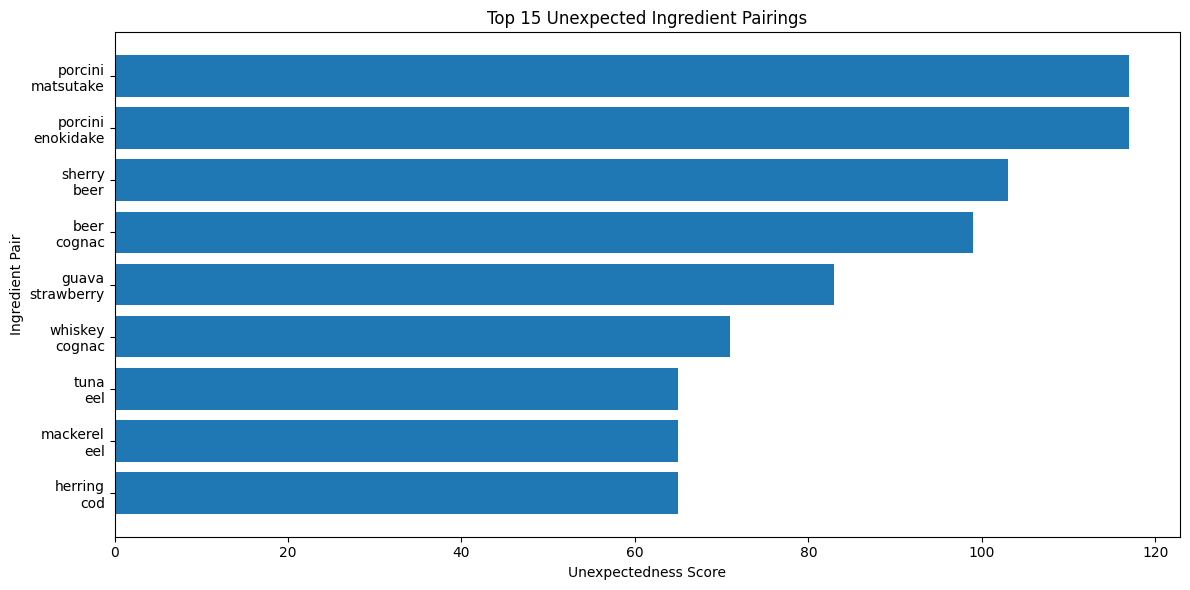

In [ ]:
plot_df = rare_pairs.head(15)

plt.figure(figsize=(12, 6))

labels = [
    f"{a}\n{b}"
    for a, b in zip(
        plot_df["ingredient_1"],
        plot_df["ingredient_2"]
    )
]

plt.barh(
    labels[::-1],
    plot_df["unexpectedness"][::-1]
)

plt.xlabel("Unexpectedness Score")
plt.ylabel("Ingredient Pair")
plt.title("Top 15 Unexpected Ingredient Pairings")

plt.tight_layout()
plt.show()

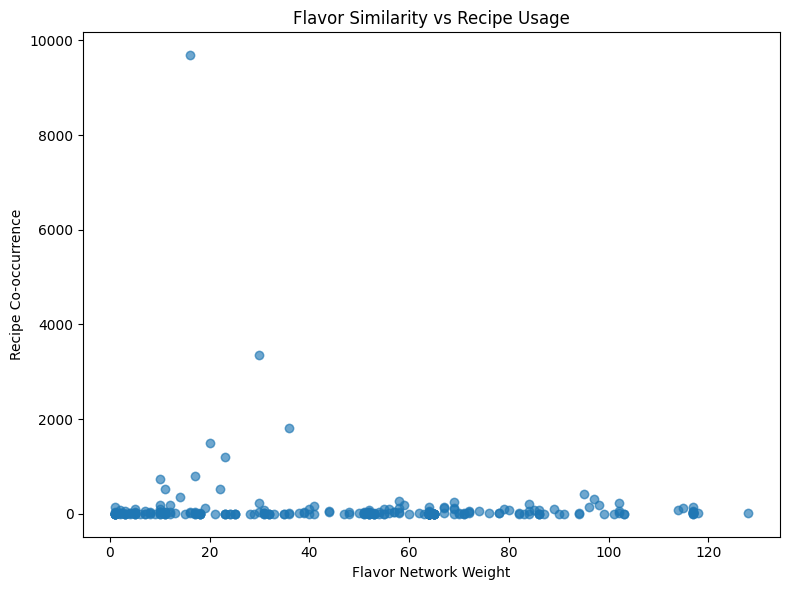

In [ ]:
sample = unexpected_df.sample(
    min(5000, len(unexpected_df)),
    random_state=42
)

plt.figure(figsize=(8, 6))

plt.scatter(
    sample["flavor_weight"],
    sample["recipe_cooccurrence"],
    alpha=0.4
)

plt.xlabel("Flavor Network Weight")
plt.ylabel("Recipe Co-occurrence")
plt.title("Flavor Similarity vs Recipe Usage")

plt.tight_layout()
plt.show()

## Network Robustness

Expectations
1. When removing the nodes with high degrees that the network will become disconnected
2. When random ingredients are removed the network is robust
3. If the the high betweeness edges are removed the network will be sensitive because they connect the ingredients of many different cuisines and the giant compnent will be divided into many small ones

In [ ]:
def giant_fraction(H):
    """Fraction of current nodes in the largest connected component."""
    if H.number_of_nodes() == 0:
        return 0.0
    return max(len(c) for c in nx.connected_components(H)) / H.number_of_nodes()


def robustness_curve(H, strategy="random", f_grid=None, seed=0):
    """Return (f_values, S_values) after removing fraction f of original N0 nodes."""
    H0 = H.copy()
    N0 = H0.number_of_nodes()
    if f_grid is None:
        f_grid = np.linspace(0, 0.5, 21)
    S = []
    local_rng = np.random.default_rng(seed)
    for f in f_grid:
        n_remove = int(round(f * N0))
        Gt = H0.copy()
        for _ in range(n_remove):
            if Gt.number_of_nodes() == 0:
                break
            if strategy == "random":
                v = local_rng.choice(list(Gt.nodes()))
            elif strategy == "degree_attack":
                v = max(Gt.degree, key=lambda kv: kv[1])[0]
            else:
                raise ValueError(strategy)
            Gt.remove_node(v)
        S.append(giant_fraction(Gt))
    return np.asarray(f_grid), np.asarray(S)


def first_f_below(f_grid, S, threshold=0.5):
    """Smallest f in grid with S(f) < threshold; None if never crosses."""
    f_grid = np.asarray(f_grid)
    S = np.asarray(S)
    mask = S < threshold
    return float(f_grid[mask][0]) if mask.any() else None


print("Sanity check on connected G: S(0) =", giant_fraction(G), "(should be 1.0)")

Sanity check on connected G: S(0) = 0.9627659574468085 (should be 1.0)


In [ ]:
H = G.copy()
N0 = H.number_of_nodes()
print("rank | k | name")
removed = []
for rank in range(1, 11):
    nid = max(H.degree, key=lambda kv: kv[1])[0]
    k = H.degree(nid)
    removed.append(nid)
    print(rank, k, nid)
    H.remove_node(nid)
gcc = max(len(c) for c in nx.connected_components(H)) if H.number_of_nodes() else 0
print("\nAfter 10 hub removals: S =", giant_fraction(H), "|GCC| =", gcc, "of", H.number_of_nodes(), "nodes left")
print("One hub alone rarely disconnects a large graph; many hubs carry global connectivity.")

rank | k | name
1 49 roasted beef
2 47 black tea
3 42 strawberry
4 32 beer
5 23 apple
6 23 parmesan cheese
7 22 blue cheese
8 20 white wine
9 19 cheddar cheese
10 17 beef

After 10 hub removals: S = 0.4371584699453552 |GCC| = 160 of 366 nodes left
One hub alone rarely disconnects a large graph; many hubs carry global connectivity.


# After removing the 10 highest degree nodes, the resilience of the network dropped to 0.44 and the giant component now has 160 nodes instead of 366, meaning that 204 nodes disconnected from the giant compoonent. When s < 0.5, the largest connected component has less than half of the nodes in the network.

In [ ]:
H1 = G.copy()
N1 = H.number_of_nodes()
print("rank | k | name")
removed = []
for rank in range(1, 2):
    nid = max(H1.degree, key=lambda kv: kv[1])[0]
    k = H1.degree(nid)
    removed.append(nid)
    print(rank, k, nid)
    H1.remove_node(nid)
gcc = max(len(c) for c in nx.connected_components(H1)) if H1.number_of_nodes() else 0
print("\nAfter 1 hub removals: S =", giant_fraction(H1), "|GCC| =", gcc, "of", H1.number_of_nodes(), "nodes left")
print("One hub alone rarely disconnects a large graph; many hubs carry global connectivity.")

rank | k | name
1 49 roasted beef

After 1 hub removals: S = 0.84 |GCC| = 315 of 375 nodes left
One hub alone rarely disconnects a large graph; many hubs carry global connectivity.


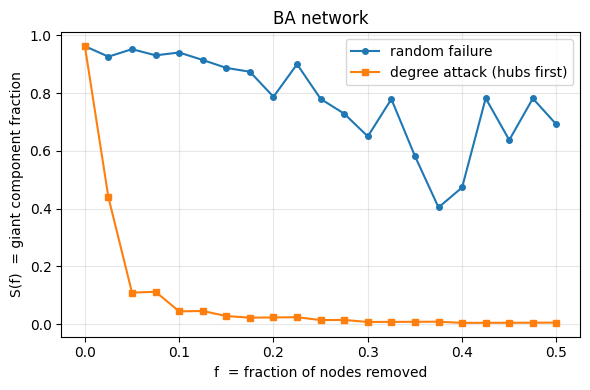

In [ ]:
f_grid = np.linspace(0, 0.5, 21)
f_ba, S_rand = robustness_curve(G, "random", f_grid=f_grid, seed=1)
_, S_att = robustness_curve(G, "degree_attack", f_grid=f_grid, seed=1)
plt.figure(figsize=(6, 4))
plt.plot(f_ba, S_rand, "o-", label="random failure", markersize=4)
plt.plot(f_ba, S_att, "s-", label="degree attack (hubs first)", markersize=4)
plt.xlabel("f  = fraction of nodes removed")
plt.ylabel("S(f)  = giant component fraction")
plt.title("Network")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

We can extarct from the graph the following conclusion: When there is degree attack the giant component fraction quickly drops meaning that the network is fragile when the hubs are targeted. However, it is somewht robust to noise under random removal of nodes.

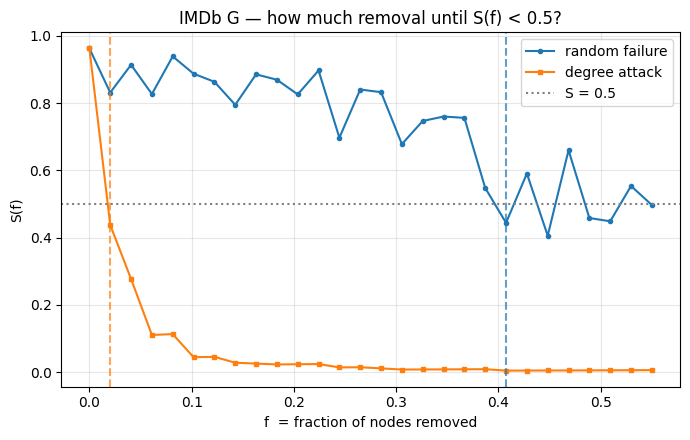

random  f* = 0.407  (~153 nodes removed of 376)  S(f*) = 0.444
attack  f* = 0.020  (~8 nodes removed of 376)  S(f*) = 0.438


In [ ]:
THRESH = 0.5
f_fine = np.linspace(0, 0.55, 28)
N0 = G.number_of_nodes()

f_r, S_r = robustness_curve(G, "random", f_grid=f_fine, seed=42)
f_a, S_a = robustness_curve(G, "degree_attack", f_grid=f_fine, seed=0)

f_break_rand = first_f_below(f_r, S_r, THRESH)
f_break_att = first_f_below(f_a, S_a, THRESH)

plt.figure(figsize=(7, 4.5))
plt.plot(f_r, S_r, "o-", label="random failure", markersize=3)
plt.plot(f_a, S_a, "s-", label="degree attack", markersize=3)
plt.axhline(THRESH, color="gray", linestyle=":", linewidth=1.5, label=f"S = {THRESH}")
if f_break_rand is not None:
    plt.axvline(f_break_rand, color="C0", linestyle="--", alpha=0.7)
if f_break_att is not None:
    plt.axvline(f_break_att, color="C1", linestyle="--", alpha=0.7)
plt.xlabel("f  = fraction of nodes removed")
plt.ylabel("S(f)")
plt.title("IMDb G — how much removal until S(f) < 0.5?")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for name, fb, fv, Sv in [("random", f_break_rand, f_r, S_r), ("attack", f_break_att, f_a, S_a)]:
    if fb is None:
        print(name, ": S stays >= 0.5 on this f grid (try larger max f)")
    else:
        n = int(round(fb * N0))
        j = int(np.argmin(np.abs(fv - fb)))
        print(f"{name:6s}  f* = {fb:.3f}  (~{n} nodes removed of {N0})  S(f*) = {Sv[j]:.3f}")

When the attack is random we need to remove almost half of the nodes before the S(f) falls below 0.5, while for degree attack only few of the high degree nodes can destroy the giant component.

In [ ]:
def giant_fraction(H):
    """Fraction of *remaining* nodes in the largest connected component."""
    if H.number_of_nodes() == 0:
        return 0.0
    return max(len(c) for c in nx.connected_components(H)) / H.number_of_nodes()


def gcc_share_of_original(H, N0):
    """Fraction of the *original* cast still in one connected story (same node set)."""
    if N0 == 0 or H.number_of_nodes() == 0:
        return 0.0
    comps = list(nx.connected_components(H))
    if not comps:
        return 0.0
    return max(len(c) for c in comps) / N0


def robustness_curve_edges(H, strategy="random", f_grid=None, seed=0, N0=None):
    """Return (f, S, P): S on remaining nodes; P = |GCC|/N0."""
    H0 = H.copy()
    L0 = H0.number_of_edges()
    if N0 is None:
        N0 = H0.number_of_nodes()
    if f_grid is None:
        f_grid = np.linspace(0, 1.0, 21)
    rng = np.random.default_rng(seed)
    S_vals, P_vals = [], []
    for f in f_grid:
        n_remove = int(round(f * L0))
        Gt = H0.copy()
        if strategy == "random":
            elist = list(Gt.edges())
            rng.shuffle(elist)
            Gt.remove_edges_from(elist[:n_remove])
        elif strategy == "edge_attack":
            for _ in range(n_remove):
                if Gt.number_of_edges() == 0:
                    break
                eb = nx.edge_betweenness_centrality(Gt)
                Gt.remove_edge(*max(eb, key=eb.get))
        else:
            raise ValueError(strategy)
        S_vals.append(giant_fraction(Gt))
        P_vals.append(gcc_share_of_original(Gt, N0))
    return np.asarray(f_grid), np.asarray(S_vals), np.asarray(P_vals)


def robustness_curve_nodes(H, strategy="random", f_grid=None, seed=0, N0=None):
    """Return (f, S, P) after removing fraction f of *original* nodes."""
    H0 = H.copy()
    N0 = N0 or H0.number_of_nodes()
    if f_grid is None:
        f_grid = np.linspace(0, 1.0, 21)
    rng = np.random.default_rng(seed)
    S_vals, P_vals = [], []
    for f in f_grid:
        n_remove = int(round(f * N0))
        Gt = H0.copy()
        for _ in range(n_remove):
            if Gt.number_of_nodes() == 0:
                break
            if strategy == "random":
                Gt.remove_node(rng.choice(list(Gt.nodes())))
            elif strategy == "degree_attack":
                Gt.remove_node(max(Gt.degree, key=lambda kv: kv[1])[0])
            else:
                raise ValueError(strategy)
        S_vals.append(giant_fraction(Gt))
        P_vals.append(gcc_share_of_original(Gt, N0))
    return np.asarray(f_grid), np.asarray(S_vals), np.asarray(P_vals)


def first_f_below(f_grid, values, threshold=0.5):
    f_grid = np.asarray(f_grid)
    values = np.asarray(values)
    mask = values < threshold
    return float(f_grid[mask][0]) if mask.any() else None


def plot_structural_dual(f, S, P, label, title_suffix="", mark_f_star=None, thresh=0.5):
    """Two-panel curve: S(f) in [0,1] and % of original cast in the GCC; x-axis always 0--100% removed."""
    fig, axes = plt.subplots(2, 1, figsize=(7, 5.4), sharex=True)
    axes[0].plot(f, S, "o-", label=label, markersize=4)
    axes[0].axhline(thresh, color="gray", linestyle=":", linewidth=1.1)
    if mark_f_star is not None:
        axes[0].axvline(mark_f_star, linestyle="--", alpha=0.75, label=f"f*={mark_f_star:.2f}")
    axes[0].set_ylabel("S(f)  (among survivors)")
    axes[0].set_ylim(0, 1.02)
    axes[0].set_xlim(0, 1)
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)
    axes[0].set_title(title_suffix or label)

    axes[1].plot(f, 100 * P, "s-", color="C1", markersize=4, label="% of Book-1 cast in GCC")
    axes[1].axhline(100 * thresh, color="gray", linestyle=":", linewidth=1.1)
    axes[1].set_xlabel("fraction removed  (0 = none, 1 = 100%)")
    axes[1].set_ylabel("% of original N in GCC")
    axes[1].set_ylim(0, 102)
    axes[1].set_xlim(0, 1)
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def _short_label(nid):
    return nid.replace("-", " ")


def draw_westeros_before_after(
    G_full,
    G_after,
    n0,
    damage_caption,
    highlight="Eddard-Stark",
    label_top_k=10,
    extra_label_nodes=None,
    removed_nodes=None,
):
    # Side-by-side maps with readable labels on major characters (fixed layout).
    extra_label_nodes = extra_label_nodes or set()
    removed_nodes = removed_nodes or set()
    pos = nx.spring_layout(G_full, seed=42, k=0.45, iterations=100)
    top = {n for n, _ in sorted(G_full.degree(), key=lambda kv: kv[1], reverse=True)[:label_top_k]}
    label_set = top | set(extra_label_nodes) | {highlight} | removed_nodes

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    def _draw_panel(ax, G, title):
        nodes = list(G.nodes())
        sizes = [80 + 12 * G.degree(n) for n in nodes]
        colors = []
        for n in nodes:
            if n == highlight:
                colors.append("crimson")
            elif n in removed_nodes:
                colors.append("gold")
            else:
                colors.append("steelblue")
        nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.2, width=0.5, edge_color="#888888")
        nx.draw_networkx_nodes(G, pos, ax=ax, node_size=sizes, node_color=colors, alpha=0.92, linewidths=0.3, edgecolors="white")
        for n in nodes:
            if n in label_set:
                x, y = pos[n]
                ax.text(
                    x, y, _short_label(n), fontsize=7, ha="center", va="center",
                    color="white", fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.15", facecolor="black", alpha=0.55, linewidth=0),
                )
        gcc_pct = 100 * gcc_share_of_original(G, n0)
        ax.set_title(f"{title}\\n{gcc_pct:.0f}% of ingredients still in the network", fontsize=10)
        ax.axis("off")

    _draw_panel(axes[0], G_full, "Before")
    _draw_panel(axes[1], G_after, f"After: {damage_caption}")
    fig.suptitle("Book 1 co-appearance network (labels on main characters)", fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()


def outbreak_character_cards(H, seeds_dict, phi, long_night_pct=30):
    """Pretty table: role, name, degree, outbreak, % of graph (nodes must be in H)."""
    n = H.number_of_nodes()
    print(f"{'role':14s} | {'name':22s} | {'k':>3s} | {'outbreak':>8s} | {'% graph':>7s}")
    print("-" * 65)
    for role, nid in seeds_dict.items():
        if nid not in H:
            print(f"{role:14s} | {nid:22s} |  n/a | (not in this subgraph)")
            continue
        k = int(H.degree(nid))
        sz = spread_white_walker_syndrome(H, [nid], phi=phi)
        flag = "  <-- Long Night" if 100 * sz / n >= long_night_pct else ""
        print(f"{role:14s} | {nid:22s} | {k:3d} | {sz:8d} | {100*sz/n:6.1f}%{flag}")


In [ ]:
def draw_westeros_before_after(
    G_full,
    G_after,
    n0,
    damage_caption,
    highlight="Eddard-Stark",
    label_top_k=10,
    extra_label_nodes=None,
    removed_nodes=None,
):
    # Side-by-side maps with readable labels on major characters (fixed layout).
    extra_label_nodes = extra_label_nodes or set()
    removed_nodes = removed_nodes or set()
    pos = nx.spring_layout(G_full, seed=42, k=0.45, iterations=100)
    top = {n for n, _ in sorted(G_full.degree(), key=lambda kv: kv[1], reverse=True)[:label_top_k]}
    label_set = top | set(extra_label_nodes) | {highlight} | removed_nodes

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    def _draw_panel(ax, G, title):
        nodes = list(G.nodes())
        sizes = [80 + 12 * G.degree(n) for n in nodes]
        colors = []
        for n in nodes:
            if n == highlight:
                colors.append("crimson")
            elif n in removed_nodes:
                colors.append("gold")
            else:
                colors.append("steelblue")
        nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.2, width=0.5, edge_color="#888888")
        nx.draw_networkx_nodes(G, pos, ax=ax, node_size=sizes, node_color=colors, alpha=0.92, linewidths=0.3, edgecolors="white")
        for n in nodes:
            if n in label_set:
                x, y = pos[n]
                ax.text(
                    x, y, _short_label(n), fontsize=7, ha="center", va="center",
                    color="white", fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.15", facecolor="black", alpha=0.55, linewidth=0),
                )
        gcc_pct = 100 * gcc_share_of_original(G, n0)
        ax.set_title(f"{title}\n {gcc_pct:.0f}% of ingredients are in the giant component", fontsize=10)
        ax.axis("off")

    _draw_panel(axes[0], G_full, "Before")
    _draw_panel(axes[1], G_after, f"After: {damage_caption}")
    fig.suptitle("Co-appearance network (labels on top degree ingredients)", fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()



Sanity: S(0)= 0.963 | % ingredients in GCC= 96.3


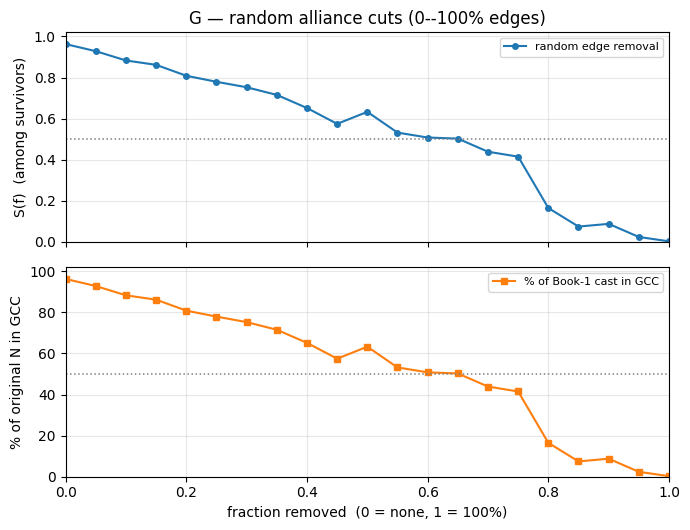

In [ ]:
f_e, S_er, P_er = robustness_curve_edges(
    G, "random", f_grid= np.linspace(0, 1.0, 21), seed=42, N0=G.number_of_nodes()
)
print("Sanity: S(0)=", round(S_er[0], 3), "| % ingredients in GCC=", round(100 * P_er[0], 1))
plot_structural_dual(
    f_e, S_er, P_er, "random edge removal", title_suffix="G — random alliance cuts (0--100% edges)"
)

betweenness | edge
    0.1305 | beer — roasted beef
    0.0962 | black tea — soybean
    0.0953 | apple — beer
    0.0680 | black tea — coffee
    0.0598 | roasted beef — coffee
    0.0582 | white wine — strawberry
    0.0572 | roasted beef — soybean
    0.0445 | black tea — bell pepper
    0.0433 | white wine — black tea
    0.0423 | black tea — ginger

After 10 bridge cuts: S=0.963 | 96% of cast in one GCC


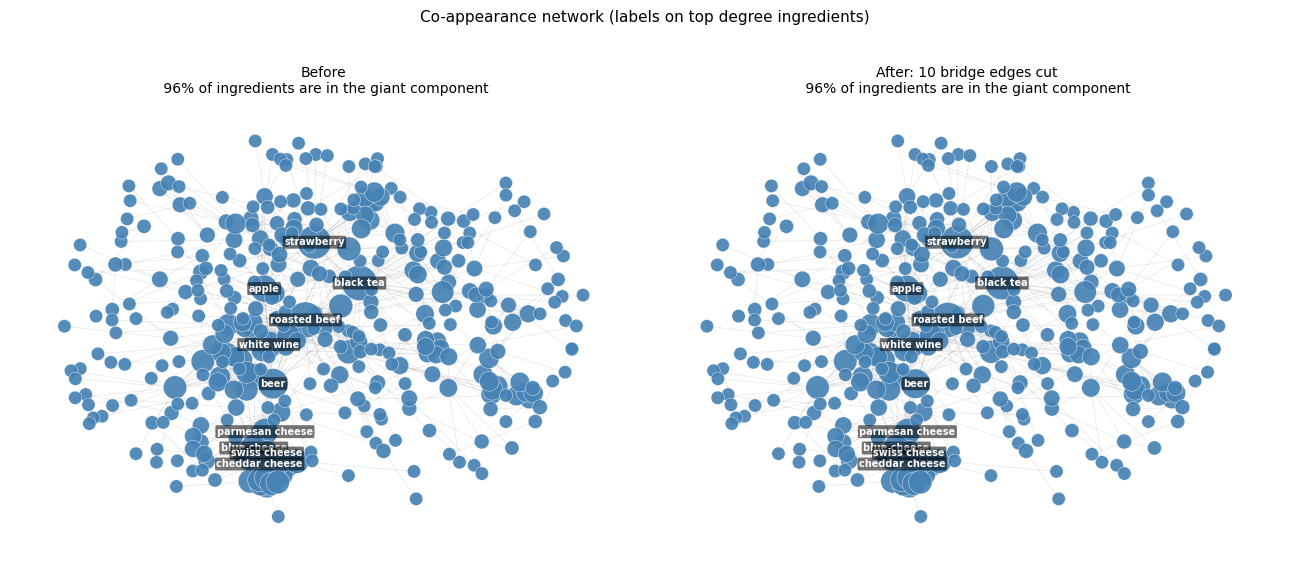

In [ ]:
N0 = G.number_of_nodes()
eb = nx.edge_betweenness_centrality(G)
top_bridges = sorted(eb.items(), key=lambda kv: kv[1], reverse=True)[:10]
print("betweenness | edge")
for e, score in top_bridges[:10]:
    print(f"{score:10.4f} | {e[0]} — {e[1]}")

G_cut = G.copy()
cut_edges = []
for e, _ in top_bridges[:10]:
    if G_cut.has_edge(*e):
        G_cut.remove_edge(*e)
        cut_edges.append(e)
bridge_endpoints = {u for e in cut_edges for u in e}
print(
    f"\nAfter 10 bridge cuts: S={giant_fraction(G_cut):.3f} | "
    f"{100*gcc_share_of_original(G_cut, N0):.0f}% of cast in one GCC"
)
draw_westeros_before_after(
    G,
    G_cut,
    N0,
    "10 bridge edges cut",
    label_top_k=10,

)

In [ ]:
print(f"Edges requested to cut : 15")
print(f"Edges actually cut     : {len(cut_edges)}")
print(f"Edges in G_cut         : {G_cut.number_of_edges()}")
print(f"Edges in G (original)  : {G.number_of_edges()}")
print(f"Difference             : {G.number_of_edges() - G_cut.number_of_edges()}")

Edges requested to cut : 15
Edges actually cut     : 10
Edges in G_cut         : 907
Edges in G (original)  : 917
Difference             : 10


# Ingredient Roles

In [ ]:
coreness = nx.core_number(G)

nodes['coreness'] = nodes['ingredient'].map(coreness)

print(f"Max coreness (innermost core): {max(coreness.values())}")
print(f"Min coreness (periphery):      {min(coreness.values())}")
print(f"\nCoreness distribution:")
print(pd.Series(coreness).value_counts().sort_index())

Max coreness (innermost core): 17
Min coreness (periphery):      1

Coreness distribution:
1     207
2      19
3      30
4      19
5      16
6       9
7      24
8       9
9      14
10     11
17     18
Name: count, dtype: int64


In [ ]:
max_core = max(coreness.values())

def assign_role(k):
    if k == max_core:
        return 'Core'
    elif k >= max_core * 0.5:
        return 'Mantle'
    else:
        return 'Periphery'

nodes['role'] = nodes['coreness'].apply(assign_role)

print("Role distribution:")
print(nodes['role'].value_counts())
print(f"\nCore ingredients ({len(nodes[nodes['role']=='Core'])}):")
print(nodes[nodes['role'] == 'Core']['ingredient'].tolist())

Role distribution:
role
Periphery    333
Mantle        25
Core          18
Name: count, dtype: int64

Core ingredients (18):
['roquefort cheese', 'romano cheese', 'camembert cheese', 'cheddar cheese', 'sheep cheese', 'emmental cheese', 'munster cheese', 'parmesan cheese', 'cream cheese', 'provolone cheese', 'gruyere cheese', 'goat cheese', 'swiss cheese', 'blue cheese', 'feta cheese', 'mozzarella cheese', 'cottage cheese', 'cheese']


In [ ]:
print("Core ingredients breakdown by category:\n")
core_by_category = (
    nodes[nodes['role'] == 'Core']
    .groupby('category')['ingredient']
    .apply(list)
)
for cat, ingredients in core_by_category.items():
    print(f"{cat} ({len(ingredients)}): {', '.join(ingredients)}")

Core ingredients breakdown by category:

Dairy (18): roquefort cheese, romano cheese, camembert cheese, cheddar cheese, sheep cheese, emmental cheese, munster cheese, parmesan cheese, cream cheese, provolone cheese, gruyere cheese, goat cheese, swiss cheese, blue cheese, feta cheese, mozzarella cheese, cottage cheese, cheese


In [ ]:
print("Role distribution per Louvain community:\n")
role_comm = pd.crosstab(nodes['community'], nodes['role'])
role_comm['total'] = role_comm.sum(axis=1)
role_comm['core_pct'] = (role_comm.get('Core', 0) / role_comm['total'] * 100).round(1)
print(role_comm.sort_values('core_pct', ascending=False).to_string())

Role distribution per Louvain community:

role       Core  Mantle  Periphery  total  core_pct
community                                          
5            18       0         13     31      58.1
0             0       0          2      2       0.0
1             0       0         15     15       0.0
2             0       0          2      2       0.0
3             0       0          5      5       0.0
4             0       0         46     46       0.0
6             0       0          3      3       0.0
7             0      14         40     54       0.0
8             0       0         69     69       0.0
9             0       0         59     59       0.0
10            0       0          8      8       0.0
11            0      11          4     15       0.0
12            0       0         25     25       0.0
13            0       0         25     25       0.0
14            0       0          2      2       0.0
15            0       0          6      6       0.0
16            0       

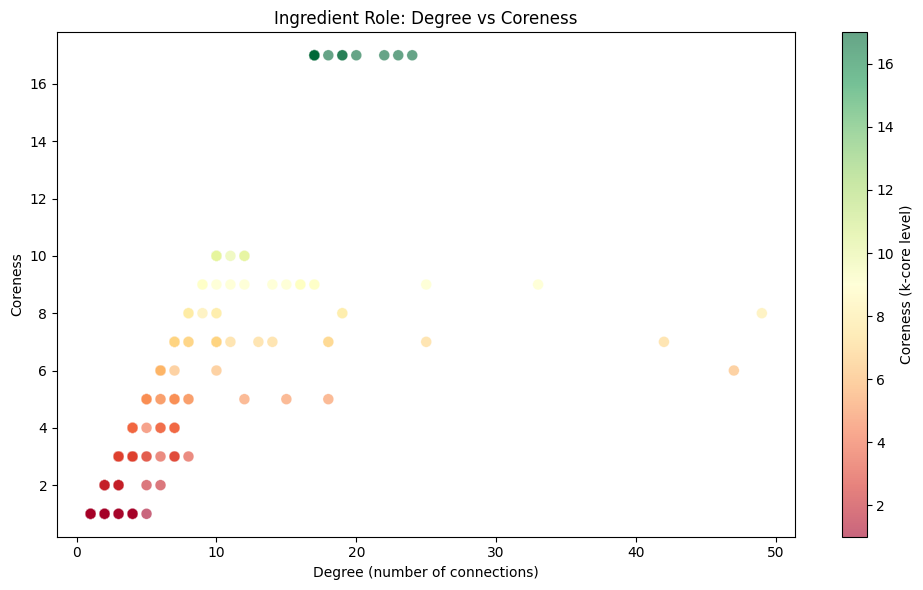

In [ ]:
x = [G.degree(n) for n in G.nodes()]
y = [coreness[n] for n in G.nodes()]
labels = list(G.nodes())

plt.figure(figsize=(10, 6))
scatter = plt.scatter(x, y, alpha=0.6, c=y, cmap='RdYlGn',
                      edgecolors='white', linewidth=0.3, s=60)
plt.colorbar(scatter, label='Coreness (k-core level)')
plt.xlabel('Degree (number of connections)')
plt.ylabel('Coreness')
plt.title('Ingredient Role: Degree vs Coreness')

plt.tight_layout()
plt.show()

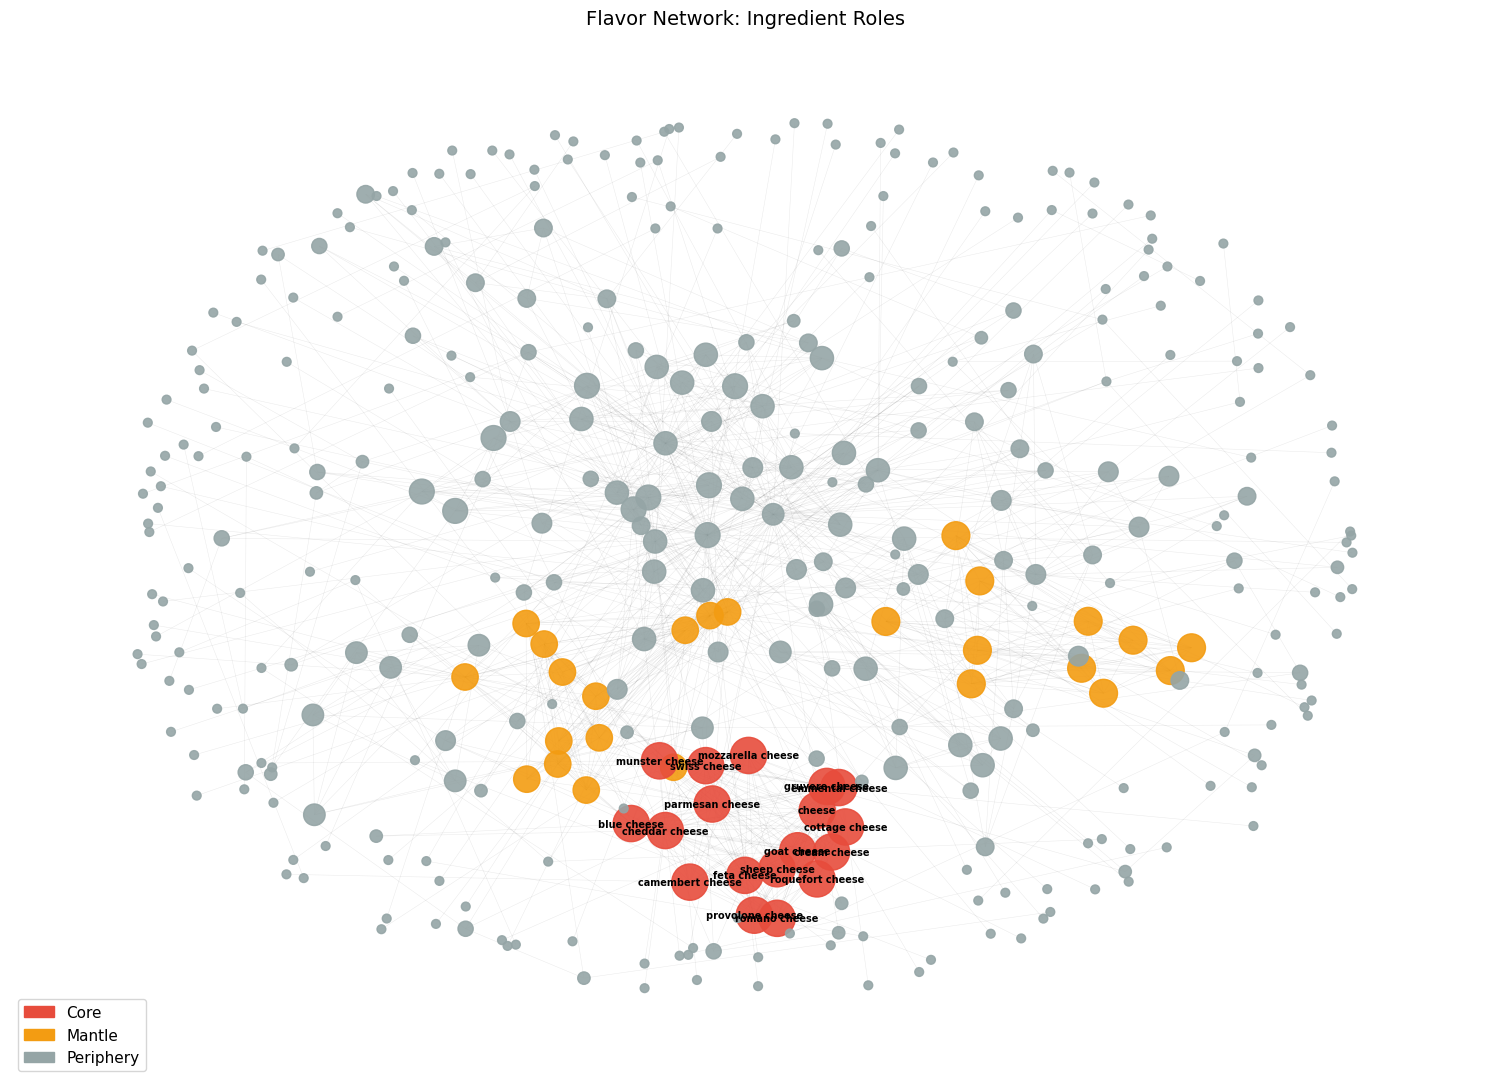

In [ ]:
role_colors = {'Core': '#e74c3c', 'Mantle': '#f39c12', 'Periphery': '#95a5a6'}
node_color_map = [role_colors[nodes.set_index('ingredient').loc[n, 'role']]
                  if n in nodes['ingredient'].values else '#95a5a6'
                  for n in G.nodes()]

node_size_map = [coreness.get(n, 1) * 40 for n in G.nodes()]

pos = nx.spring_layout(G, seed=42, k=0.5)

plt.figure(figsize=(15, 11))
nx.draw_networkx_edges(G, pos, alpha=0.08, width=0.4)
nx.draw_networkx_nodes(G, pos, node_color=node_color_map,
                       node_size=node_size_map, alpha=0.9)

core_nodes = nodes[nodes['role'] == 'Core']['ingredient'].tolist()
core_labels = {n: n for n in G.nodes() if n in core_nodes}
nx.draw_networkx_labels(G, pos, labels=core_labels, font_size=7, font_weight='bold')

from matplotlib.patches import Patch
legend = [Patch(color='#e74c3c', label='Core'),
          Patch(color='#f39c12', label='Mantle'),
          Patch(color='#95a5a6', label='Periphery')]
plt.legend(handles=legend, loc='lower left', fontsize=11)
plt.title('Flavor Network: Ingredient Roles', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

## Project Summary & Conclusions: Flavor Network Analysis

### 1. Network Topology & Small-World Properties
*   **Small-World confirmed:** The flavor network exhibits a high clustering coefficient ($C \approx 0.31$) and short average path lengths ($L \approx 4.27$). This confirms the **Small-World property** ($σ \approx 18.5$), meaning most ingredients are just a few 'flavor steps' away from each other.
*   **Degree Distribution:** The network follows a typical power-law-like distribution, where a few 'hubs' (like roasted beef, black tea, and strawberry) have many connections, while most ingredients have very few.

### 2. Community Detection: Do Algorithms 'Rediscover' Food Groups?
*   **Alignment with Culinary Logic:** Louvain community detection successfully identified 18 distinct communities. Many of these communities align closely with traditional food categories:
    *   **Community 5:** Dominated by **Dairy** (71% dominant category).
    *   **Community 11:** Highly concentrated with **Seafood** (93.3%).
    *   **Community 4:** Focused on **Fruits** (71.7%).
*   **Emergent Relationships:** Some communities show mixed pairings (e.g., Community 8 mixing vegetables and meats), reflecting common culinary bases like 'mirepoix' or 'sofrito' components.

### 3. Network Robustness & Sensitivity
*   **Resilience to Random Failures:** The network is robust against the random loss of ingredients. We can remove roughly **40% of nodes** before the giant component collapses.
*   **Vulnerability to Targeted Attacks:** The network is highly fragile if 'hubs' (key ingredients) are removed. Removing just the **top 2% of hubs** (8 nodes) can reduce the giant component size by half. This suggests that certain ingredients are structurally vital for flavor diversity.
*   **Bridge Edges:** Connectivity relies on critical bridges (e.g., *Beer — Roasted Beef*). Cutting these specific flavor-sharing paths significantly impacts the global connectivity of the network.

### 4. Ingredient Roles: Core vs. Periphery
*   **The Dairy Core:** K-core decomposition reveals a tight 'innermost core' consisting almost entirely of **Dairy products** (cheeses like Roquefort, Romano, and Parmesan). These ingredients share a high number of compounds with each other and serve as a central cluster in the flavor space.
*   **The Periphery:** The majority of ingredients (88%) occupy the periphery, meaning they have more specialized flavor profiles that only link to a few other nodes.

### 5. Discovery of Unexpected Pairings
*   **The Flavor Pairing Hypothesis:** By comparing shared compounds (network weight) with recipe co-occurrence, we identified 'Surprise Pairings' — combinations that share high chemical similarity but are rarely used together in the dataset.
*   **Key Discoveries:**
    *   **Fungi:** *Porcini* and *Enokidake* / *Matsutake* (High similarity, low co-occurrence).
    *   **Beverages:** *Sherry* and *Beer*.
    *   **Fruit/Berry:** *Guava* and *Strawberry*.
*   **Culinary Application:** These results provide a data-driven map for 'Food Pairing' innovation, suggesting new combinations for chefs and food scientists based on molecular commonality.